# Klasifikace nádorů mozku pomocí CNN

**Dataset:** Brain Tumor Classification MRI — [Kaggle (sartajbhuvaji)](https://www.kaggle.com/datasets/sartajbhuvaji/brain-tumor-classification-mri)  
**Cíl:** Klasifikace MRI snímků mozku do 4 kategorií nádorů  
**Přístupy:** Vlastní CNN od nuly · Transfer Learning (EfficientNetB0)

In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, models, callbacks
from tensorflow.keras.applications import EfficientNetB0
from sklearn.model_selection import train_test_split
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import f1_score, accuracy_score, confusion_matrix, classification_report
from PIL import Image
import mlflow
import optuna
optuna.logging.set_verbosity(optuna.logging.WARNING)
import warnings
warnings.filterwarnings('ignore')

tf.random.set_seed(42)
np.random.seed(42)

gpus = tf.config.list_physical_devices('GPU')
if gpus:
    for gpu in gpus:
        tf.config.experimental.set_memory_growth(gpu, True)
    print(f"GPU nalezeno: {gpus[0].name}")
else:
    print("GPU nenalezeno – trénink běží na CPU.")

TRAIN_DIR       = "./data/brain/Training"
TEST_DIR        = "./data/brain/Testing"
IMG_SIZE        = 150
BATCH_SIZE      = 32
NUM_CLASSES     = 4
EPOCHS          = 50
CLASS_NAMES     = ['glioma_tumor', 'meningioma_tumor', 'no_tumor', 'pituitary_tumor']
CLASS_LABELS_CZ = ['Gliom', 'Meningiom', 'Bez nádoru', 'Hypofýza']

print(f"\nTensorFlow {tf.__version__}")

I0000 00:00:1780823329.133491   43648 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
/home/ajra/Code/HU/venv/lib64/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


GPU nalezeno: /physical_device:GPU:0

TensorFlow 2.21.0


## 1. Dokumentace datasetu

**Dataset:** [Brain Tumor Classification MRI](https://www.kaggle.com/datasets/sartajbhuvaji/brain-tumor-classification-mri) (Kaggle)

| Parametr | Hodnota |
|---|---|
| Celkový počet snímků | **3 264** (2 870 trénink + 394 test) |
| Počet tříd | **4** |
| Modalita | MRI (magnetická rezonance mozku) |
| Formát | RGB JPEG, různá rozlišení |

**Rozložení tříd (tréninková sada):**

| Třída | Tréninková | Testovací | Celkem |
|---|---|---|---|
| glioma\_tumor | 826 | 100 | 926 |
| meningioma\_tumor | 822 | 115 | 937 |
| no\_tumor | 395 | 105 | 500 |
| pituitary\_tumor | 827 | 74 | 901 |

**Nevyvážení tříd:** Třída `no_tumor` tvoří pouze ~14 % trénovacích dat oproti ~29 % u ostatních tříd. Tento nepoměr je kompenzován váhami tříd (`class_weight`) při tréninku.

In [2]:
records = []
for split, directory in [('Training', TRAIN_DIR), ('Testing', TEST_DIR)]:
    for cls in sorted(os.listdir(directory)):
        cls_path = os.path.join(directory, cls)
        if os.path.isdir(cls_path):
            count = len([f for f in os.listdir(cls_path) if f.lower().endswith(('.jpg', '.jpeg', '.png'))])
            records.append({'Split': split, 'Třída': cls, 'Počet': count})
stats_df = pd.DataFrame(records)
pivot = stats_df.pivot(index='Třída', columns='Split', values='Počet').fillna(0).astype(int)
pivot['Celkem'] = pivot.sum(axis=1)
print(pivot.to_string())
print(f"\nCelkový počet snímků: {pivot['Celkem'].sum()}")
print(f"Počet tříd: {NUM_CLASSES}")
print(f"Doménová klasifikace: Klasifikace obrazů (Image Classification)")
print(f"Modalita: MRI (Magnetická rezonance mozku)")

Split             Testing  Training  Celkem
Třída                                      
glioma_tumor          100       826     926
meningioma_tumor      115       822     937
no_tumor              105       395     500
pituitary_tumor        74       827     901

Celkový počet snímků: 3264
Počet tříd: 4
Doménová klasifikace: Klasifikace obrazů (Image Classification)
Modalita: MRI (Magnetická rezonance mozku)


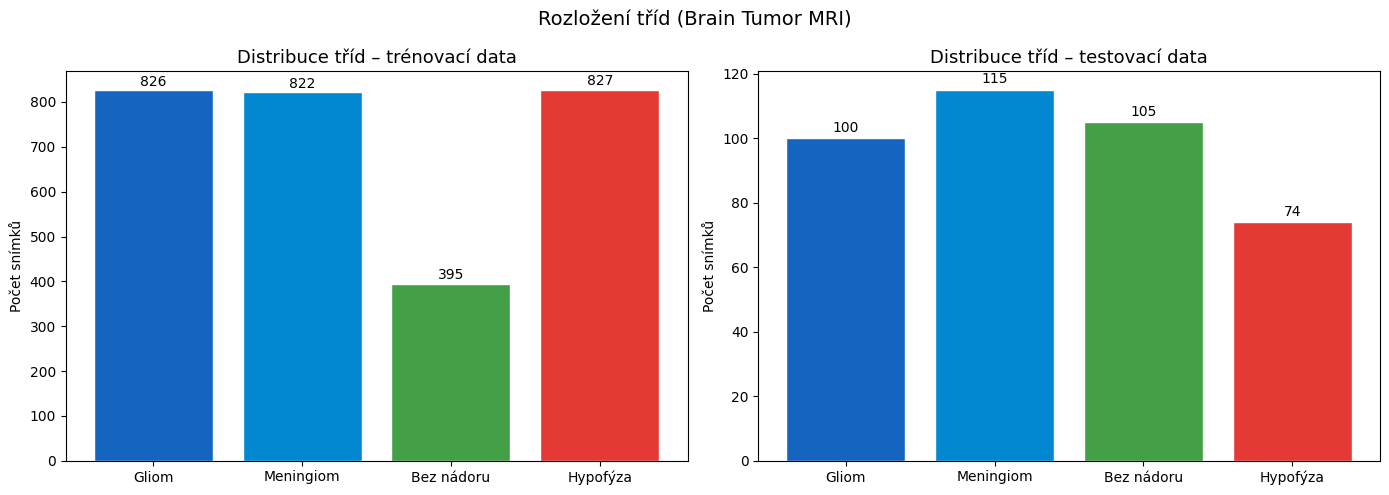

In [3]:
train_counts = stats_df[stats_df['Split'] == 'Training'].set_index('Třída')['Počet']
test_counts  = stats_df[stats_df['Split'] == 'Testing'].set_index('Třída')['Počet']

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
colors = ['#1565c0', '#0288d1', '#43a047', '#e53935']

axes[0].bar(CLASS_LABELS_CZ, [train_counts[c] for c in CLASS_NAMES], color=colors, edgecolor='white')
axes[0].set_title('Distribuce tříd – trénovací data', fontsize=13)
axes[0].set_ylabel('Počet snímků')
for i, v in enumerate([train_counts[c] for c in CLASS_NAMES]):
    axes[0].text(i, v + 10, str(v), ha='center', fontsize=10)

axes[1].bar(CLASS_LABELS_CZ, [test_counts[c] for c in CLASS_NAMES], color=colors, edgecolor='white')
axes[1].set_title('Distribuce tříd – testovací data', fontsize=13)
axes[1].set_ylabel('Počet snímků')
for i, v in enumerate([test_counts[c] for c in CLASS_NAMES]):
    axes[1].text(i, v + 2, str(v), ha='center', fontsize=10)

plt.suptitle('Rozložení tříd (Brain Tumor MRI)', fontsize=14)
plt.tight_layout()
plt.show()

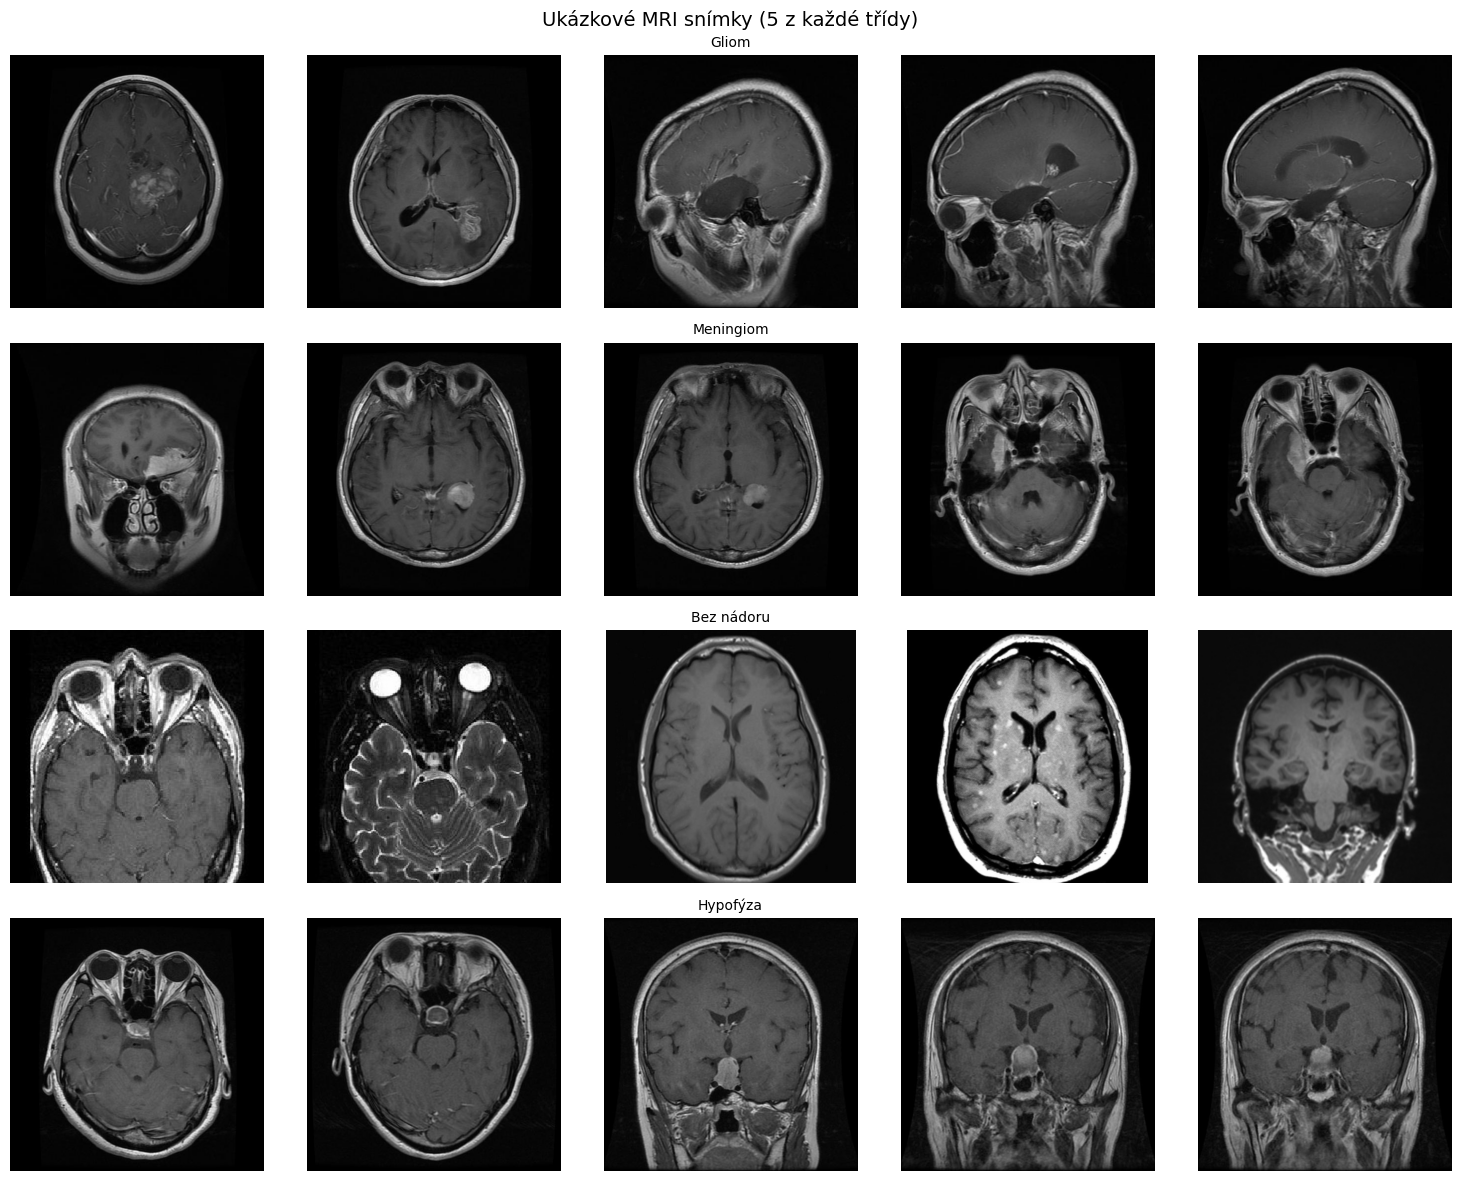

In [4]:
fig, axes = plt.subplots(4, 5, figsize=(15, 12))
for row, cls in enumerate(CLASS_NAMES):
    cls_path = os.path.join(TRAIN_DIR, cls)
    files = sorted(os.listdir(cls_path))[:5]
    for col, fname in enumerate(files):
        img = Image.open(os.path.join(cls_path, fname)).convert('RGB')
        axes[row, col].imshow(img)
        axes[row, col].set_title(CLASS_LABELS_CZ[row] if col == 2 else '', fontsize=10)
        axes[row, col].axis('off')
plt.suptitle('Ukázkové MRI snímky (5 z každé třídy)', fontsize=14)
plt.tight_layout()
plt.show()

**Pozorování:**
- MRI snímky mozku mají různé rozlišení a orientaci (axiální, sagitální, koronální řez).
- Třída `no_tumor` je podreprezentovaná (~14 % trénovacích dat oproti ~29 % pro ostatní třídy) — důvod pro použití vah tříd.
- Nádory se liší umístěním, tvarem i velikostí — model musí zachytit jemné strukturální příznaky.
- Dataset je typem **klasifikace obrazů** s medicínskou doménou (MRI neuroimaging).

## 2. Příprava dat

In [5]:
def load_images(directory, img_size=IMG_SIZE):
    """Načte obrázky do numpy pole, normalizuje do [0, 1]."""
    X, y = [], []
    classes = sorted(os.listdir(directory))
    classes = [c for c in classes if os.path.isdir(os.path.join(directory, c))]
    for label, cls in enumerate(classes):
        cls_path = os.path.join(directory, cls)
        for img_file in sorted(os.listdir(cls_path)):
            if not img_file.lower().endswith(('.jpg', '.jpeg', '.png')):
                continue
            try:
                img = Image.open(os.path.join(cls_path, img_file)).convert('RGB').resize((img_size, img_size))
                X.append(np.array(img, dtype=np.float32) / 255.0)
                y.append(label)
            except Exception:
                pass
    return np.array(X), np.array(y)

print("Načítám trénovací data...")
X_all, y_all = load_images(TRAIN_DIR)
print(f"X_all: {X_all.shape}")

print("Načítám testovací data...")
X_test, y_test = load_images(TEST_DIR)
print(f"X_test: {X_test.shape}")

# Stratifikovaný split 80/20
X_train, X_val, y_train, y_val = train_test_split(
    X_all, y_all, test_size=0.2, random_state=42, stratify=y_all
)
print(f"\nTrénink: {len(X_train)} | Validace: {len(X_val)} | Test: {len(X_test)}")

Načítám trénovací data...
X_all: (2870, 150, 150, 3)
Načítám testovací data...
X_test: (394, 150, 150, 3)

Trénink: 2296 | Validace: 574 | Test: 394


Váhy tříd:
  Gliom          : 0.868
  Meningiom      : 0.874
  Bez nádoru     : 1.816
  Hypofýza      : 0.867


I0000 00:00:1780823341.658666   43648 gpu_device.cc:2043] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 3998 MB memory:  -> device: 0, name: NVIDIA GeForce GTX 1660 Ti, pci bus id: 0000:07:00.0, compute capability: 7.5


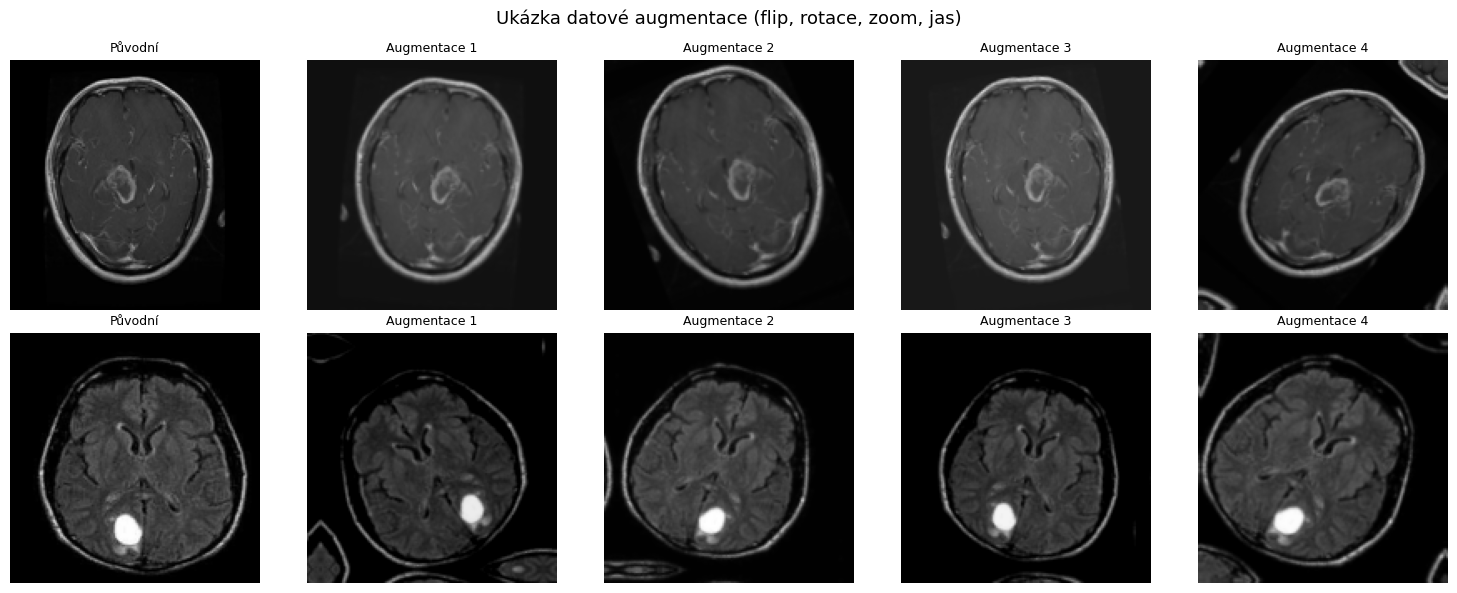

In [6]:
# Váhy tříd pro vyvážení nevyváženého datasetu (no_tumor má méně vzorků)
cw = compute_class_weight('balanced', classes=np.arange(NUM_CLASSES), y=y_train)
class_weight_dict = dict(enumerate(cw))
print("Váhy tříd:")
for i, cls in enumerate(CLASS_NAMES):
    print(f"  {CLASS_LABELS_CZ[i]:<15}: {class_weight_dict[i]:.3f}")

# Ukázka augmentace
aug_model = models.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.15),
    layers.RandomZoom(0.15),
    layers.RandomBrightness(0.1, value_range=(0, 1)),
])

fig, axes = plt.subplots(2, 5, figsize=(15, 6))
sample_img = X_train[0:1]
axes[0, 0].imshow(sample_img[0])
axes[0, 0].set_title('Původní', fontsize=9)
axes[0, 0].axis('off')
for i in range(1, 5):
    aug = aug_model(sample_img, training=True)
    axes[0, i].imshow(aug[0].numpy())
    axes[0, i].set_title(f'Augmentace {i}', fontsize=9)
    axes[0, i].axis('off')
sample_img2 = X_train[5:6]
axes[1, 0].imshow(sample_img2[0])
axes[1, 0].set_title('Původní', fontsize=9)
axes[1, 0].axis('off')
for i in range(1, 5):
    aug = aug_model(sample_img2, training=True)
    axes[1, i].imshow(aug[0].numpy())
    axes[1, i].set_title(f'Augmentace {i}', fontsize=9)
    axes[1, i].axis('off')
plt.suptitle('Ukázka datové augmentace (flip, rotace, zoom, jas)', fontsize=13)
plt.tight_layout()
plt.show()

## 3. Výběr hodnotících metrik

**Zdůvodnění volby F1-macro jako hlavní metriky:**  
Dataset je nevyvážený — třída `no_tumor` má výrazně méně vzorků (~14 %) než ostatní třídy (~29 %).
V medicínském kontextu je falešně negativní klasifikace nádoru zvláště nebezpečná — model označí nádor jako nepřítomný, přestože přítomen je.
F1-macro dává každé třídě stejnou váhu bez ohledu na počet vzorků a penalizuje selhání na každé třídě stejnou měrou.
Accuracy zůstává sekundární metrikou pro snadnou interpretaci.

**Poznámka k EarlyStopping:** Monitorujeme `val_accuracy` místo `val_loss`.
Na validační sadě může `val_loss` klesat, zatímco `val_accuracy` stagnuje — nebo naopak: epocha s nejnižším `val_loss` nemusí odpovídat nejlepší přesnosti. `ReduceLROnPlateau` nadále sleduje `val_loss`, protože ten poskytuje hladší signál pro snížení LR.

In [7]:
from sklearn.metrics import precision_score, recall_score

def evaluate_model(model, X, y_true, label="Model"):
    y_pred = np.argmax(model.predict(X, verbose=0), axis=1)
    acc  = accuracy_score(y_true, y_pred)
    f1   = f1_score(y_true, y_pred, average='macro', zero_division=0)
    prec = precision_score(y_true, y_pred, average='macro', zero_division=0)
    rec  = recall_score(y_true, y_pred, average='macro', zero_division=0)
    print(f"{label:<50}  Accuracy={acc:.4f}  Precision={prec:.4f}  Recall={rec:.4f}  F1-macro={f1:.4f}")
    return acc, f1, y_pred

def plot_history(history, title):
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))
    ax1.plot(history.history['accuracy'],     label='trénink')
    ax1.plot(history.history['val_accuracy'], label='validace')
    ax1.set_title(f'{title} – Accuracy')
    ax1.set_xlabel('Epocha')
    ax1.legend()
    ax2.plot(history.history['loss'],     label='trénink')
    ax2.plot(history.history['val_loss'], label='validace')
    ax2.set_title(f'{title} – Loss')
    ax2.set_xlabel('Epocha')
    ax2.legend()
    plt.tight_layout()
    plt.show()

base_callbacks = [
    callbacks.EarlyStopping(
        monitor='val_accuracy', patience=15, mode='max',
        restore_best_weights=True, verbose=1
    ),
    callbacks.ReduceLROnPlateau(
        monitor='val_loss', factor=0.5, patience=7, verbose=0
    ),
]

## 4. Model 1 – Vlastní CNN

**Architektura (VGG-style):** 4 bloky, každý s dvojicí konvolucí a následným MaxPoolingem.  
Prostorové rozlišení: 150→75→37→18→9 px; GlobalAveragePooling místo Flatten.  
Filtry: 64 → 128 → 256 → 256 (zdvojení kapacity oproti předchozí 3blokové verzi).  
`SpatialDropout2D` po prvních třech blocích (bloky 1–3) — zahazuje celé kanály mapy příznaků, efektivnější než bodový Dropout pro CNN. Čtvrtý blok (256 filtrů) SpatialDropout2D neobsahuje.  
Inicializace `he_normal` je vhodná pro aktivaci ReLU (udržuje rozptyl gradientů napříč vrstvami).

**Augmentace** (pouze při tréninku): horizontální zrcadlení, rotace ±54° (`RandomRotation(0.15)` = ±15 % z 360°), zoom ±10 %, jas ±10 %.

| Varianta | Změna |
|---|---|
| **CNN + BN + Adam** | hlavní model |
| **CNN bez BN** | zjistit vliv BatchNorm na konvergenci |
| **CNN + BN + SGD+Nesterov** | porovnání optimalizátorů |


In [ ]:
def build_cnn(use_bn=True, optimizer='adam', dropout_rate=0.2, name="CNN"):
    from tensorflow.keras.regularizers import l2

    inp = layers.Input(shape=(IMG_SIZE, IMG_SIZE, 3))

    # Augmentace pouze při tréninku (vrstva v modelu)
    x = layers.RandomFlip("horizontal")(inp)
    x = layers.RandomRotation(0.15)(x)
    x = layers.RandomZoom(0.1)(x)
    x = layers.RandomBrightness(0.1, value_range=(0, 1))(x)

    # Blok 1 – 64 filtrů
    x = layers.Conv2D(64, 3, padding='same', activation='relu',
                      kernel_initializer='he_normal', kernel_regularizer=l2(1e-4))(x)
    x = layers.Conv2D(64, 3, padding='same', activation='relu',
                      kernel_initializer='he_normal', kernel_regularizer=l2(1e-4))(x)
    if use_bn: x = layers.BatchNormalization()(x)
    x = layers.MaxPooling2D(2)(x)          # 150 → 75
    x = layers.SpatialDropout2D(dropout_rate)(x)

    # Blok 2 – 128 filtrů
    x = layers.Conv2D(128, 3, padding='same', activation='relu',
                      kernel_initializer='he_normal', kernel_regularizer=l2(1e-4))(x)
    x = layers.Conv2D(128, 3, padding='same', activation='relu',
                      kernel_initializer='he_normal', kernel_regularizer=l2(1e-4))(x)
    if use_bn: x = layers.BatchNormalization()(x)
    x = layers.MaxPooling2D(2)(x)          # 75 → 37
    x = layers.SpatialDropout2D(dropout_rate)(x)

    # Blok 3 – 256 filtrů
    x = layers.Conv2D(256, 3, padding='same', activation='relu',
                      kernel_initializer='he_normal', kernel_regularizer=l2(1e-4))(x)
    x = layers.Conv2D(256, 3, padding='same', activation='relu',
                      kernel_initializer='he_normal', kernel_regularizer=l2(1e-4))(x)
    if use_bn: x = layers.BatchNormalization()(x)
    x = layers.MaxPooling2D(2)(x)          # 37 → 18
    x = layers.SpatialDropout2D(dropout_rate)(x)

    # Blok 4 – 256 filtrů
    x = layers.Conv2D(256, 3, padding='same', activation='relu',
                      kernel_initializer='he_normal', kernel_regularizer=l2(1e-4))(x) 
    x = layers.Conv2D(256, 3, padding='same', activation='relu',
                      kernel_initializer='he_normal', kernel_regularizer=l2(1e-4))(x)
    if use_bn: x = layers.BatchNormalization()(x)
    x = layers.MaxPooling2D(2)(x)          # 18 → 9

    # Klasifikační hlava
    x = layers.GlobalAveragePooling2D()(x)
    x = layers.Dense(512, activation='relu', kernel_initializer='he_normal')(x)
    x = layers.Dropout(0.5)(x)
    out = layers.Dense(NUM_CLASSES, activation='softmax')(x)

    opt = keras.optimizers.Adam(1e-3) if optimizer == 'adam' else optimizer
    model = models.Model(inp, out, name=name)
    model.compile(optimizer=opt, loss='sparse_categorical_crossentropy', metrics=['accuracy'])
    return model

cnn_main = build_cnn(use_bn=True, optimizer='adam', name="CNN_BN_Adam")
cnn_main.summary()

Model: "CNN_BN_Adam"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 150, 150, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ random_flip_1 (RandomFlip)      │ (None, 150, 150, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ random_rotation_1               │ (None, 150, 150, 3)    │             0 │
│ (RandomRotation)                │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ random_zoom_1 (RandomZoom)      │ (None, 150, 150, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ random_brightness_1             │ (None, 150, 150, 3)    │             0 │
│ (RandomBrightness)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 150, 150, 64)   │         1,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 150, 150, 64)   │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 150, 150, 64)   │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 75, 75, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ spatial_dropout2d               │ (None, 75, 75, 64)     │             0 │
│ (SpatialDropout2D)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 75, 75, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 75, 75, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 75, 75, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 37, 37, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ spatial_dropout2d_1             │ (None, 37, 37, 128)    │             0 │
│ (SpatialDropout2D)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 37, 37, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 37, 37, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 37, 37, 256)    │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 18, 18, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ spatial_dropout2d_2             │ (None, 18, 18, 256)    │             0 │
│ (SpatialDropout2D)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_6 (Conv2D)               │ (None, 18, 18, 256)    │       590,08

 Total params: 2,462,020 (9.39 MB)

 Trainable params: 2,460,612 (9.39 MB)

 Non-trainable params: 1,408 (5.50 KB)

In [9]:
history_cnn = cnn_main.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    class_weight=class_weight_dict,
    callbacks=base_callbacks,
    verbose=1
)

W0000 00:00:1780823344.816577   43648 cpu_allocator_impl.cc:82] Allocation of 619920000 exceeds 10% of free system memory.
W0000 00:00:1780823345.239600   43648 cpu_allocator_impl.cc:82] Allocation of 619920000 exceeds 10% of free system memory.


Epoch 1/50


E0000 00:00:1780823348.943457   43648 meta_optimizer.cc:967] layout failed: INVALID_ARGUMENT: Size of values 0 does not match size of permutation 4 @ fanin shape inStatefulPartitionedCall/CNN_BN_Adam_1/spatial_dropout2d_1/stateless_dropout/SelectV2-2-TransposeNHWCToNCHW-LayoutOptimizer
I0000 00:00:1780823349.723818   43847 cuda_dnn.cc:461] Loaded cuDNN version 92000
W0000 00:00:1780823350.256720   43847 bfc_allocator.cc:311] Allocator (GPU_0_bfc) ran out of memory trying to allocate 3.04GiB with freed_by_count=0. The caller indicates that this is not a failure, but this may mean that there could be performance gains if more memory were available.
W0000 00:00:1780823351.080208   43847 bfc_allocator.cc:311] Allocator (GPU_0_bfc) ran out of memory trying to allocate 2.55GiB with freed_by_count=0. The caller indicates that this is not a failure, but this may mean that there could be performance gains if more memory were available.
W0000 00:00:1780823351.444794   43847 bfc_allocator.cc:311]

72/72 ━━━━━━━━━━━━━━━━━━━━ 0s 302ms/step - accuracy: 0.4216 - loss: 1.8769

W0000 00:00:1780823378.552814   43840 bfc_allocator.cc:383] Garbage collection: deallocate free memory regions (i.e., allocations) so that we can re-allocate a larger region to avoid OOM due to memory fragmentation. If you see this message frequently, you are running near the threshold of the available device memory and re-allocation may incur great performance overhead. You may try smaller batch sizes to observe the performance impact. Set TF_ENABLE_GPU_GARBAGE_COLLECTION=false if you'd like to disable this feature.


72/72 ━━━━━━━━━━━━━━━━━━━━ 33s 343ms/step - accuracy: 0.4678 - loss: 1.6607 - val_accuracy: 0.4460 - val_loss: 1.6065 - learning_rate: 0.0010
Epoch 2/50
72/72 ━━━━━━━━━━━━━━━━━━━━ 19s 268ms/step - accuracy: 0.5449 - loss: 1.3665 - val_accuracy: 0.3972 - val_loss: 1.7494 - learning_rate: 0.0010
Epoch 3/50
72/72 ━━━━━━━━━━━━━━━━━━━━ 19s 267ms/step - accuracy: 0.5610 - loss: 1.2818 - val_accuracy: 0.2578 - val_loss: 2.0195 - learning_rate: 0.0010
Epoch 4/50
72/72 ━━━━━━━━━━━━━━━━━━━━ 19s 266ms/step - accuracy: 0.6272 - loss: 1.1759 - val_accuracy: 0.4686 - val_loss: 1.4911 - learning_rate: 0.0010
Epoch 5/50
72/72 ━━━━━━━━━━━━━━━━━━━━ 19s 265ms/step - accuracy: 0.6463 - loss: 1.1385 - val_accuracy: 0.3014 - val_loss: 1.7837 - learning_rate: 0.0010
Epoch 6/50
72/72 ━━━━━━━━━━━━━━━━━━━━ 19s 265ms/step - accuracy: 0.6620 - loss: 1.0628 - val_accuracy: 0.6777 - val_loss: 1.0893 - learning_rate: 0.0010
Epoch 7/50
72/72 ━━━━━━━━━━━━━━━━━━━━ 19s 265ms/step - accuracy: 0.6912 - loss: 1.0131 - val_

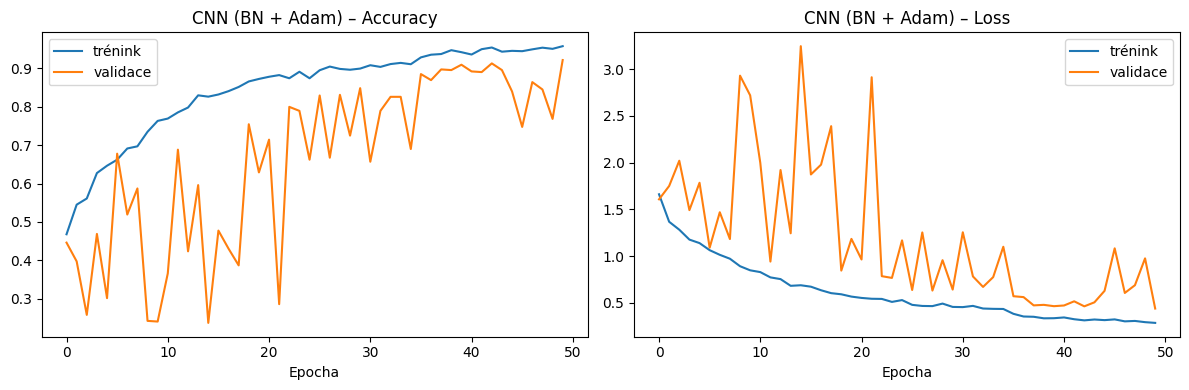

CNN (BN+Adam) – validace                            Accuracy=0.9216  Precision=0.9190  Recall=0.9203  F1-macro=0.9172
CNN (BN+Adam) – test                                Accuracy=0.6650  Precision=0.7353  Recall=0.6513  F1-macro=0.6338


In [10]:
plot_history(history_cnn, "CNN (BN + Adam)")
acc_cnn,   f1_cnn,   pred_cnn_val = evaluate_model(cnn_main, X_val,  y_val,  "CNN (BN+Adam) – validace")
acc_cnn_t, f1_cnn_t, pred_cnn_t   = evaluate_model(cnn_main, X_test, y_test, "CNN (BN+Adam) – test")

### Experimenty – vliv BatchNormalization a optimalizátoru

Trénujeme tři varianty se shodnou architekturou, měníme vždy jen jeden parametr.

W0000 00:00:1780824313.039016   43648 cpu_allocator_impl.cc:82] Allocation of 619920000 exceeds 10% of free system memory.
W0000 00:00:1780824313.458486   43648 cpu_allocator_impl.cc:82] Allocation of 619920000 exceeds 10% of free system memory.
E0000 00:00:1780824316.028267   43648 meta_optimizer.cc:967] layout failed: INVALID_ARGUMENT: Size of values 0 does not match size of permutation 4 @ fanin shape inStatefulPartitionedCall/CNN_noBN_1/spatial_dropout2d_3_1/stateless_dropout/SelectV2-2-TransposeNHWCToNCHW-LayoutOptimizer


Epoch 15: early stopping
Restoring model weights from the end of the best epoch: 1.
CNN (bez BN) – validace                             Accuracy=0.3171  Precision=0.1765  Recall=0.2758  F1-macro=0.1594


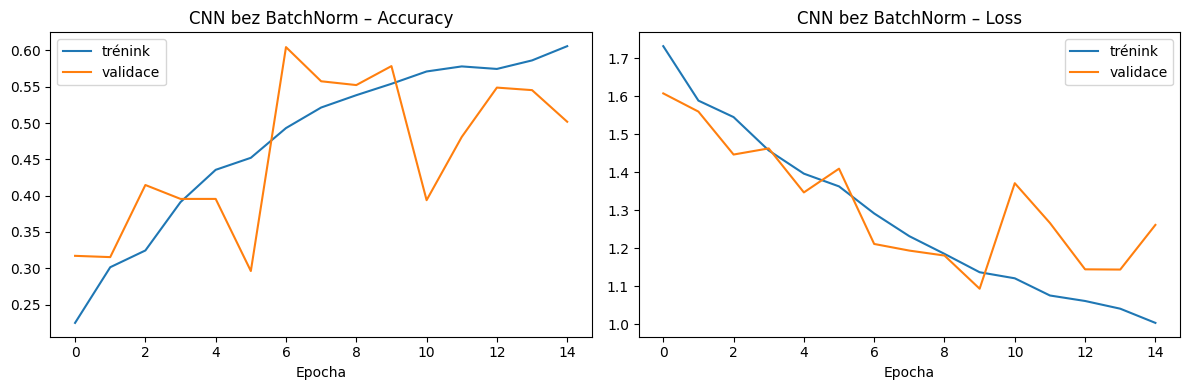

In [11]:
tf.random.set_seed(42)
np.random.seed(42)
cnn_nobn = build_cnn(use_bn=False, optimizer='adam', name="CNN_noBN")
history_nobn = cnn_nobn.fit(
    X_train, y_train, validation_data=(X_val, y_val),
    epochs=EPOCHS, batch_size=BATCH_SIZE,
    class_weight=class_weight_dict,
    callbacks=base_callbacks, verbose=0
)
acc_nobn, f1_nobn, _ = evaluate_model(cnn_nobn, X_val, y_val, "CNN (bez BN) – validace")
plot_history(history_nobn, "CNN bez BatchNorm")

W0000 00:00:1780824537.653613   43648 cpu_allocator_impl.cc:82] Allocation of 619920000 exceeds 10% of free system memory.
E0000 00:00:1780824540.699589   43648 meta_optimizer.cc:967] layout failed: INVALID_ARGUMENT: Size of values 0 does not match size of permutation 4 @ fanin shape inStatefulPartitionedCall/CNN_BN_SGD_1/spatial_dropout2d_6_1/stateless_dropout/SelectV2-2-TransposeNHWCToNCHW-LayoutOptimizer


Epoch 15: early stopping
Restoring model weights from the end of the best epoch: 1.
CNN (BN + SGD) – validace                           Accuracy=0.1620  Precision=0.5481  Recall=0.2613  F1-macro=0.1116


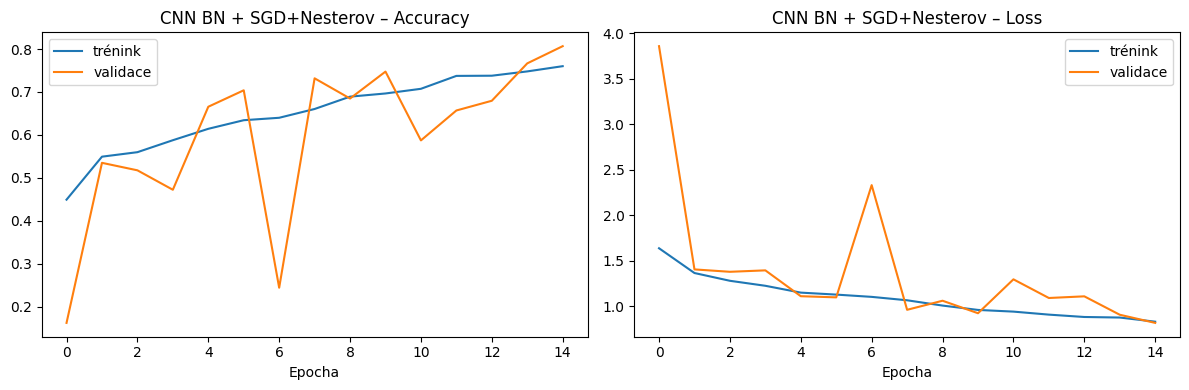

In [12]:
tf.random.set_seed(42)
np.random.seed(42)
sgd = keras.optimizers.SGD(learning_rate=0.01, momentum=0.9, nesterov=True)
cnn_sgd = build_cnn(use_bn=True, optimizer=sgd, name="CNN_BN_SGD")
history_sgd = cnn_sgd.fit(
    X_train, y_train, validation_data=(X_val, y_val),
    epochs=EPOCHS, batch_size=BATCH_SIZE,
    class_weight=class_weight_dict,
    callbacks=base_callbacks, verbose=0
)
acc_sgd, f1_sgd, _ = evaluate_model(cnn_sgd, X_val, y_val, "CNN (BN + SGD) – validace")
plot_history(history_sgd, "CNN BN + SGD+Nesterov")

In [13]:
exp_df = pd.DataFrame({
    'Varianta':     ['CNN + BN + Adam', 'CNN bez BN + Adam', 'CNN + BN + SGD+Nesterov'],
    'Val Accuracy': [f"{acc_cnn:.4f}",  f"{acc_nobn:.4f}",  f"{acc_sgd:.4f}"],
    'Val F1-macro': [f"{f1_cnn:.4f}",   f"{f1_nobn:.4f}",   f"{f1_sgd:.4f}"],
    'Epochy': [
        len(history_cnn.history['loss']),
        len(history_nobn.history['loss']),
        len(history_sgd.history['loss'])
    ],
})
exp_df

,Varianta,Val Accuracy,Val F1-macro,Epochy
0,CNN + BN + Adam,0.9216,0.9172,50
1,CNN bez BN + Adam,0.3171,0.1594,15
2,CNN + BN + SGD+Nesterov,0.1620,0.1116,15


**Pozorování:**
- **BatchNorm je klíčový pro konvergenci** — CNN s BN (Val Acc=0.9216, F1=0.9172) dramaticky překonal variantu bez BN (Val Acc=0.3171, F1=0.1594). Bez normalizace aktivací se gradient šíří nestabilně a model se neposunul za triviální baseline.
- **Adam výrazně překonal SGD** — SGD s lr=0.01 a Nesterovem selhalo úplně (Val Acc=0.1620, best epoch=1, EarlyStopping zastavil po 15 epochách). Adam s výchozím LR=0.001 konvergoval stabilně k vysoké přesnosti.
- **Val vs Test gap u vítěze (CNN+BN+Adam):** Val Acc=0.9216 vs Test Acc=0.6650 — rozdíl 0.27 naznačuje distribuční posun mezi `Training/` a `Testing/` adresářem nebo overfitting na validační sadě.
- **Závěr:** Kombinace BatchNorm + Adam je nezbytná podmínka konvergence vlastní CNN na tomto datasetu.

## 5. Model 2 – Transfer Learning (EfficientNetB0)

EfficientNetB0 předtrénovaný na ImageNet (4.0M parametrů v bázi, 4.2M celkem) — váhy zachycují obecné vizuální příznaky (hrany, textury, tvary), které jsou přenositelné na medicínské MRI snímky.

**Fáze 1 – Feature extraction:** Báze zmrazena, trénujeme pouze klasifikační hlavu.  
**Fáze 2 – Fine-tuning:** Odmrazíme posledních 20 vrstev, doladíme s velmi nízkým LR (5e-6).

**Poznámka k Rescaling vrstvě:** EfficientNetB0 očekává vstup v rozsahu [0, 255] — model má vestavěný preprocessing. Přidáme vrstvu `Rescaling(255.0)`, která převede normalizovaný vstup [0, 1] zpět na očekávaný rozsah.


In [14]:
base_model = EfficientNetB0(
    weights='imagenet', include_top=False,
    input_shape=(IMG_SIZE, IMG_SIZE, 3)
)
base_model.trainable = False
print(f"EfficientNetB0: {len(base_model.layers)} vrstev, {base_model.count_params():,} parametrů")

inp = layers.Input(shape=(IMG_SIZE, IMG_SIZE, 3))
x = layers.RandomFlip("horizontal")(inp)
x = layers.RandomRotation(0.15)(x)
x = layers.RandomZoom(0.1)(x)
# EfficientNetB0 očekává vstup v [0, 255] – model má vestavěný preprocessing
x = layers.Rescaling(255.0)(x)
x = base_model(x)
x = layers.GlobalAveragePooling2D()(x)
x = layers.Dropout(0.3)(x)
x = layers.Dense(128, activation='relu')(x)
x = layers.Dropout(0.2)(x)
out = layers.Dense(NUM_CLASSES, activation='softmax')(x)
tl_model = models.Model(inp, out, name="TL_EfficientNetB0")

tl_model.compile(
    optimizer=keras.optimizers.Adam(1e-3),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

tl_callbacks = [
    callbacks.EarlyStopping(
        monitor='val_loss', patience=15,
        restore_best_weights=True, verbose=1
    ),
    callbacks.ReduceLROnPlateau(
        monitor='val_loss', factor=0.5, patience=7, verbose=0
    ),
]

print("Fáze 1 – trénink klasifikační hlavy (báze zmrazena)")
history_tl1 = tl_model.fit(
    X_train, y_train, validation_data=(X_val, y_val),
    epochs=EPOCHS, batch_size=BATCH_SIZE,
    class_weight=class_weight_dict,
    callbacks=tl_callbacks, verbose=1
)

EfficientNetB0: 238 vrstev, 4,049,571 parametrů
Fáze 1 – trénink klasifikační hlavy (báze zmrazena)
Epoch 1/50


E0000 00:00:1780824836.287622   43648 meta_optimizer.cc:967] layout failed: INVALID_ARGUMENT: Size of values 0 does not match size of permutation 4 @ fanin shape inStatefulPartitionedCall/TL_EfficientNetB0_1/efficientnetb0_1/block2b_drop_1/stateless_dropout/SelectV2-2-TransposeNHWCToNCHW-LayoutOptimizer


72/72 ━━━━━━━━━━━━━━━━━━━━ 14s 102ms/step - accuracy: 0.6546 - loss: 0.8309 - val_accuracy: 0.7213 - val_loss: 0.7681 - learning_rate: 0.0010
Epoch 2/50
72/72 ━━━━━━━━━━━━━━━━━━━━ 4s 55ms/step - accuracy: 0.7530 - loss: 0.6184 - val_accuracy: 0.7317 - val_loss: 0.7667 - learning_rate: 0.0010
Epoch 3/50
72/72 ━━━━━━━━━━━━━━━━━━━━ 4s 53ms/step - accuracy: 0.7875 - loss: 0.5097 - val_accuracy: 0.7770 - val_loss: 0.6612 - learning_rate: 0.0010
Epoch 4/50
72/72 ━━━━━━━━━━━━━━━━━━━━ 4s 53ms/step - accuracy: 0.8088 - loss: 0.4801 - val_accuracy: 0.7753 - val_loss: 0.6009 - learning_rate: 0.0010
Epoch 5/50
72/72 ━━━━━━━━━━━━━━━━━━━━ 4s 54ms/step - accuracy: 0.8136 - loss: 0.4636 - val_accuracy: 0.7875 - val_loss: 0.5795 - learning_rate: 0.0010
Epoch 6/50
72/72 ━━━━━━━━━━━━━━━━━━━━ 4s 53ms/step - accuracy: 0.8132 - loss: 0.4526 - val_accuracy: 0.7718 - val_loss: 0.6159 - learning_rate: 0.0010
Epoch 7/50
72/72 ━━━━━━━━━━━━━━━━━━━━ 4s 53ms/step - accuracy: 0.8227 - loss: 0.4267 - val_accuracy: 0.

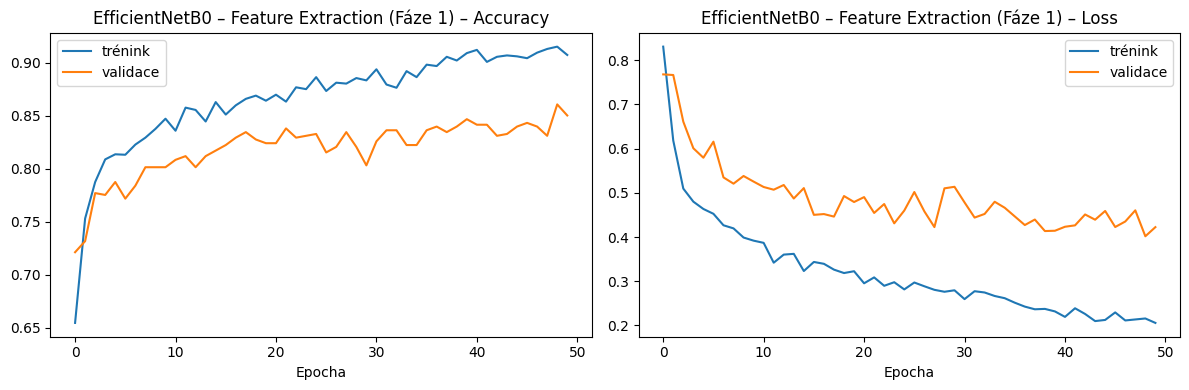

EfficientNetB0 Fáze 1 (frozen) – validace           Accuracy=0.8606  Precision=0.8660  Recall=0.8689  F1-macro=0.8657


(0.8606271777003485,
 0.8657152476904912,
 array([1, 2, 0, 1, 0, 3, 2, 3, 0, 1, 2, 1, 2, 1, 2, 3, 0, 3, 0, 1, 1, 3,
        0, 1, 3, 0, 1, 3, 3, 3, 0, 1, 2, 1, 2, 1, 0, 0, 3, 1, 0, 1, 1, 0,
        0, 0, 2, 3, 1, 0, 3, 1, 0, 0, 0, 1, 0, 0, 1, 3, 3, 1, 3, 0, 1, 3,
        0, 3, 1, 3, 3, 3, 1, 2, 3, 2, 3, 1, 3, 2, 3, 0, 3, 0, 3, 0, 3, 0,
        1, 1, 0, 3, 1, 3, 2, 3, 1, 3, 1, 1, 0, 0, 3, 0, 3, 3, 0, 3, 0, 0,
        0, 2, 3, 1, 0, 0, 1, 1, 1, 0, 3, 3, 0, 0, 3, 3, 2, 2, 2, 3, 2, 3,
        3, 0, 3, 1, 0, 0, 0, 3, 2, 1, 2, 3, 0, 1, 2, 3, 0, 2, 3, 3, 0, 0,
        1, 2, 3, 3, 0, 2, 1, 3, 3, 1, 0, 3, 3, 2, 3, 0, 3, 2, 1, 2, 3, 0,
        1, 0, 1, 0, 0, 1, 3, 1, 0, 0, 3, 0, 0, 1, 1, 1, 3, 3, 2, 3, 2, 3,
        1, 3, 1, 1, 0, 3, 1, 1, 2, 1, 1, 1, 1, 3, 3, 3, 2, 3, 0, 1, 2, 0,
        0, 1, 3, 3, 1, 0, 1, 1, 2, 0, 0, 2, 0, 3, 3, 1, 0, 0, 0, 1, 1, 3,
        3, 1, 3, 1, 0, 1, 3, 0, 3, 3, 1, 1, 2, 3, 2, 1, 0, 2, 2, 2, 3, 3,
        0, 0, 0, 1, 0, 3, 1, 1, 0, 3, 3, 3, 2, 0, 1, 2, 0, 3, 0, 3, 3,

In [15]:
plot_history(history_tl1, "EfficientNetB0 – Feature Extraction (Fáze 1)")
evaluate_model(tl_model, X_val, y_val, "EfficientNetB0 Fáze 1 (frozen) – validace")

In [16]:
base_model.trainable = True
for layer in base_model.layers[:-20]:
    layer.trainable = False
print(f"Trénovaných vrstev v bázi: {sum(l.trainable for l in base_model.layers)}/{len(base_model.layers)}")

tl_model.compile(
    optimizer=keras.optimizers.Adam(5e-6),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

# Důležité: nové instance callbacku – Fáze 1 callback má uložený stav (best val_loss)
# a Fáze 2 by ho nikdy nepřekonal → trénink by okamžitě skončil
tl_callbacks_p2 = [
    callbacks.EarlyStopping(
        monitor='val_loss', patience=12,
        restore_best_weights=True, verbose=1
    ),
    callbacks.ReduceLROnPlateau(
        monitor='val_loss', factor=0.5, patience=5, verbose=0
    ),
]

history_tl2 = tl_model.fit(
    X_train, y_train, validation_data=(X_val, y_val),
    epochs=30, batch_size=BATCH_SIZE,
    class_weight=class_weight_dict,
    callbacks=tl_callbacks_p2, verbose=1
)

Trénovaných vrstev v bázi: 20/238
Epoch 1/30


E0000 00:00:1780825045.277941   43648 meta_optimizer.cc:967] layout failed: INVALID_ARGUMENT: Size of values 0 does not match size of permutation 4 @ fanin shape inStatefulPartitionedCall/TL_EfficientNetB0_1/efficientnetb0_1/block2b_drop_1/stateless_dropout/SelectV2-2-TransposeNHWCToNCHW-LayoutOptimizer


72/72 ━━━━━━━━━━━━━━━━━━━━ 14s 88ms/step - accuracy: 0.6355 - loss: 1.1533 - val_accuracy: 0.8258 - val_loss: 0.5510 - learning_rate: 5.0000e-06
Epoch 2/30
72/72 ━━━━━━━━━━━━━━━━━━━━ 4s 58ms/step - accuracy: 0.6864 - loss: 0.9874 - val_accuracy: 0.7700 - val_loss: 0.6884 - learning_rate: 5.0000e-06
Epoch 3/30
72/72 ━━━━━━━━━━━━━━━━━━━━ 4s 58ms/step - accuracy: 0.7047 - loss: 0.8677 - val_accuracy: 0.7631 - val_loss: 0.7459 - learning_rate: 5.0000e-06
Epoch 4/30
72/72 ━━━━━━━━━━━━━━━━━━━━ 4s 58ms/step - accuracy: 0.7282 - loss: 0.7522 - val_accuracy: 0.7596 - val_loss: 0.7473 - learning_rate: 5.0000e-06
Epoch 5/30
72/72 ━━━━━━━━━━━━━━━━━━━━ 4s 58ms/step - accuracy: 0.7583 - loss: 0.6870 - val_accuracy: 0.7648 - val_loss: 0.7302 - learning_rate: 5.0000e-06
Epoch 6/30
72/72 ━━━━━━━━━━━━━━━━━━━━ 4s 58ms/step - accuracy: 0.7670 - loss: 0.6496 - val_accuracy: 0.7700 - val_loss: 0.7149 - learning_rate: 5.0000e-06
Epoch 7/30
72/72 ━━━━━━━━━━━━━━━━━━━━ 4s 58ms/step - accuracy: 0.7661 - loss: 0.

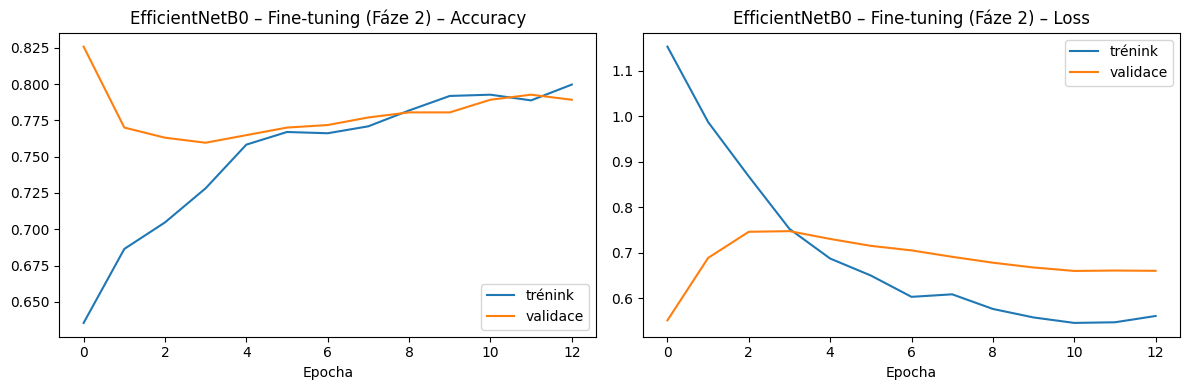

EfficientNetB0 (fine-tuned) – validace              Accuracy=0.8258  Precision=0.8238  Recall=0.8353  F1-macro=0.8251
EfficientNetB0 (fine-tuned) – test                  Accuracy=0.6421  Precision=0.6968  Recall=0.6320  F1-macro=0.5834


In [17]:
plot_history(history_tl2, "EfficientNetB0 – Fine-tuning (Fáze 2)")
acc_tl,   f1_tl,   pred_tl_val = evaluate_model(tl_model, X_val,  y_val,  "EfficientNetB0 (fine-tuned) – validace")
acc_tl_t, f1_tl_t, pred_tl_t   = evaluate_model(tl_model, X_test, y_test, "EfficientNetB0 (fine-tuned) – test")

**Pozorování k Fine-tuningu:**
- Fine-tuning Fáze 2 **zhoršil** výsledky oproti Fázi 1: Val Acc 0.8606 → 0.8258, Val F1-macro 0.8657 → 0.8251. EarlyStopping restauroval váhy z epochy 1, model z fine-tuningu fakticky neprofitoval.
- Příčinou je pravděpodobně distribuční posun mezi ImageNet a medicínskou MRI doménou — nízké LR 5e-6 nestačilo přizpůsobit konvoluční příznaky novému vizuálnímu stylu snímků.
- Příliš vysoké LR ve Fázi 2 by způsobilo katastrofické zapomenutí předtrénovaných příznaků; příliš nízké (jako zde) neumožní efektivní adaptaci.
- **Nové instance callbacků jsou zásadní:** Fáze 1 callback ukládá nejlepší `val_loss` z Fáze 1; při restartu Fáze 2 by EarlyStopping okamžitě zastavil trénink, protože nová počáteční `val_loss` je vyšší.

## 6. Sledování experimentů (MLflow)

MLflow loguje parametry a metriky obou modelů do lokálního `mlruns/` adresáře.  
Výsledky lze prohlížet příkazem: `mlflow ui`

MLflow umožňuje porovnat různé experimenty, reprodukovat výsledky a sdílet metriky v týmu.

In [18]:
mlflow.set_tracking_uri("mlruns")
mlflow.set_experiment("brain-tumor-classification")

# Log CNN výsledků
with mlflow.start_run(run_name="Custom_CNN_BN_Adam"):
    mlflow.log_params({
        "model_type": "Custom CNN",
        "img_size": IMG_SIZE,
        "batch_size": BATCH_SIZE,
        "optimizer": "Adam",
        "learning_rate": 0.001,
        "use_bn": True,
        "epochs_trained": len(history_cnn.history['loss']),
        "num_classes": NUM_CLASSES
    })
    for i, (loss, val_loss, acc, val_acc) in enumerate(zip(
        history_cnn.history['loss'], history_cnn.history['val_loss'],
        history_cnn.history['accuracy'], history_cnn.history['val_accuracy']
    )):
        mlflow.log_metrics({"train_loss": loss, "val_loss": val_loss,
                            "train_accuracy": acc, "val_accuracy": val_acc}, step=i)
    mlflow.log_metrics({"test_accuracy": acc_cnn_t, "test_f1_macro": f1_cnn_t})
    print(f"CNN run zalogován: test_accuracy={acc_cnn_t:.4f}, test_f1={f1_cnn_t:.4f}")

# Log EfficientNetB0 výsledků
with mlflow.start_run(run_name="EfficientNetB0_FineTuned"):
    mlflow.log_params({
        "model_type": "EfficientNetB0",
        "img_size": IMG_SIZE,
        "batch_size": BATCH_SIZE,
        "optimizer_phase1": "Adam_1e-3",
        "optimizer_phase2": "Adam_5e-6",
        "epochs_phase1": len(history_tl1.history['loss']),
        "epochs_phase2": len(history_tl2.history['loss']),
        "fine_tuned_layers": 20,
        "num_classes": NUM_CLASSES
    })
    for i, (loss, val_loss, acc, val_acc) in enumerate(zip(
        history_tl2.history['loss'], history_tl2.history['val_loss'],
        history_tl2.history['accuracy'], history_tl2.history['val_accuracy']
    )):
        mlflow.log_metrics({"train_loss": loss, "val_loss": val_loss,
                            "train_accuracy": acc, "val_accuracy": val_acc}, step=i)
    mlflow.log_metrics({"test_accuracy": acc_tl_t, "test_f1_macro": f1_tl_t})
    print(f"EfficientNetB0 run zalogován: test_accuracy={acc_tl_t:.4f}, test_f1={f1_tl_t:.4f}")

print("\nExperimenty uloženy do ./mlruns/")

CNN run zalogován: test_accuracy=0.6650, test_f1=0.6338
EfficientNetB0 run zalogován: test_accuracy=0.6421, test_f1=0.5834

Experimenty uloženy do ./mlruns/


## 7. Ladění hyperparametrů (Optuna)

Optuna prohledává hyperparametrický prostor CNN pomocí TPE sampleru (Tree-structured Parzen Estimator).  
Každý trial trénuje model po 15 epoch s EarlyStopping (patience=5) a vrací val F1-macro jako optimalizovanou metriku.

Z důvodu omezení GPU paměti používají Optuna trially zmenšené rozlišení 96×96 px (místo 150×150) a menší modely — výsledky jsou přenositelné, protože relativní pořadí hyperparametrů se zachovává.

Prohledávaný prostor:
- **lr:** logaritmicky rovnoměrně z [1e-4, 1e-2]
- **dropout:** rovnoměrně z [0.1, 0.5]
- **dense_units:** kategoricky z {64, 128, 256}
- **batch_size:** kategoricky z {16, 32}

In [19]:
# Přesamplujeme data jednou před studií — uvnitř trialu by se to opakovalo 10×
OPTUNA_IMG_SIZE = 96  # menší rozlišení než hlavní modely — šetří GPU paměť při ladění

def _resize_batch(X, size):
    """Přesampluje dávku obrázků na zadané rozlišení."""
    return np.array([
        np.array(Image.fromarray((img * 255).astype('uint8')).resize((size, size)),
                 dtype=np.float32) / 255.0
        for img in X
    ])

print("Přesamplování dat pro Optuna trially...")
X_tr_small  = _resize_batch(X_train, OPTUNA_IMG_SIZE)
X_val_small = _resize_batch(X_val,   OPTUNA_IMG_SIZE)
print(f"X_tr_small: {X_tr_small.shape}  X_val_small: {X_val_small.shape}")

def build_cnn_optuna(trial):
    lr           = trial.suggest_float("lr", 1e-4, 1e-2, log=True)
    dropout_rate = trial.suggest_float("dropout", 0.1, 0.5)
    dense_units  = trial.suggest_categorical("dense_units", [64, 128, 256])

    inp = layers.Input(shape=(OPTUNA_IMG_SIZE, OPTUNA_IMG_SIZE, 3))
    x = layers.RandomFlip("horizontal")(inp)
    x = layers.RandomRotation(0.1)(x)

    for filters in [32, 64, 128]:
        x = layers.Conv2D(filters, 3, padding='same', activation='relu',
                          kernel_initializer='he_normal')(x)
        x = layers.BatchNormalization()(x)
        x = layers.MaxPooling2D(2)(x)
        x = layers.Dropout(dropout_rate)(x)

    x = layers.GlobalAveragePooling2D()(x)
    x = layers.Dense(dense_units, activation='relu')(x)
    x = layers.Dropout(0.5)(x)
    out = layers.Dense(NUM_CLASSES, activation='softmax')(x)

    model = models.Model(inp, out)
    model.compile(
        optimizer=keras.optimizers.Adam(lr),
        loss='sparse_categorical_crossentropy',
        metrics=['accuracy']
    )
    return model

def objective(trial):
    # Uvolnění GPU paměti před každým trialem — zabraňuje OOM chybě
    tf.keras.backend.clear_session()
    tf.random.set_seed(trial.number)

    batch_size = trial.suggest_categorical("batch_size", [16, 32])
    model = build_cnn_optuna(trial)

    optuna_cb = [
        callbacks.EarlyStopping(monitor='val_accuracy', patience=5, mode='max',
                                restore_best_weights=True, verbose=0)
    ]
    model.fit(
        X_tr_small, y_train,
        validation_data=(X_val_small, y_val),
        epochs=15,
        batch_size=batch_size,
        class_weight=class_weight_dict,
        callbacks=optuna_cb,
        verbose=0
    )
    y_pred = np.argmax(model.predict(X_val_small, verbose=0), axis=1)
    val_f1 = f1_score(y_val, y_pred, average='macro', zero_division=0)

    del model
    tf.keras.backend.clear_session()
    return val_f1

study = optuna.create_study(direction="maximize", sampler=optuna.samplers.TPESampler(seed=42))
study.optimize(objective, n_trials=10)

print(f"\nNejlepší hyperparametry (val F1-macro = {study.best_value:.4f}):")
for k, v in study.best_params.items():
    print(f"  {k}: {v}")


Přesamplování dat pro Optuna trially...
X_tr_small: (2296, 96, 96, 3)  X_val_small: (574, 96, 96, 3)


E0000 00:00:1780825111.970953   43648 meta_optimizer.cc:967] layout failed: INVALID_ARGUMENT: Size of values 0 does not match size of permutation 4 @ fanin shape inStatefulPartitionedCall/functional_1/dropout_1/stateless_dropout/SelectV2-2-TransposeNHWCToNCHW-LayoutOptimizer
E0000 00:00:1780825188.020213   43648 meta_optimizer.cc:967] layout failed: INVALID_ARGUMENT: Size of values 0 does not match size of permutation 4 @ fanin shape inStatefulPartitionedCall/functional_1/dropout_1/stateless_dropout/SelectV2-2-TransposeNHWCToNCHW-LayoutOptimizer
E0000 00:00:1780825285.574247   43648 meta_optimizer.cc:967] layout failed: INVALID_ARGUMENT: Size of values 0 does not match size of permutation 4 @ fanin shape inStatefulPartitionedCall/functional_1/dropout_1/stateless_dropout/SelectV2-2-TransposeNHWCToNCHW-LayoutOptimizer
E0000 00:00:1780825370.227054   43648 meta_optimizer.cc:967] layout failed: INVALID_ARGUMENT: Size of values 0 does not match size of permutation 4 @ fanin shape inStateful


Nejlepší hyperparametry (val F1-macro = 0.7926):
  batch_size: 16
  lr: 0.001217284708112243
  dropout: 0.15636968998990508
  dense_units: 256


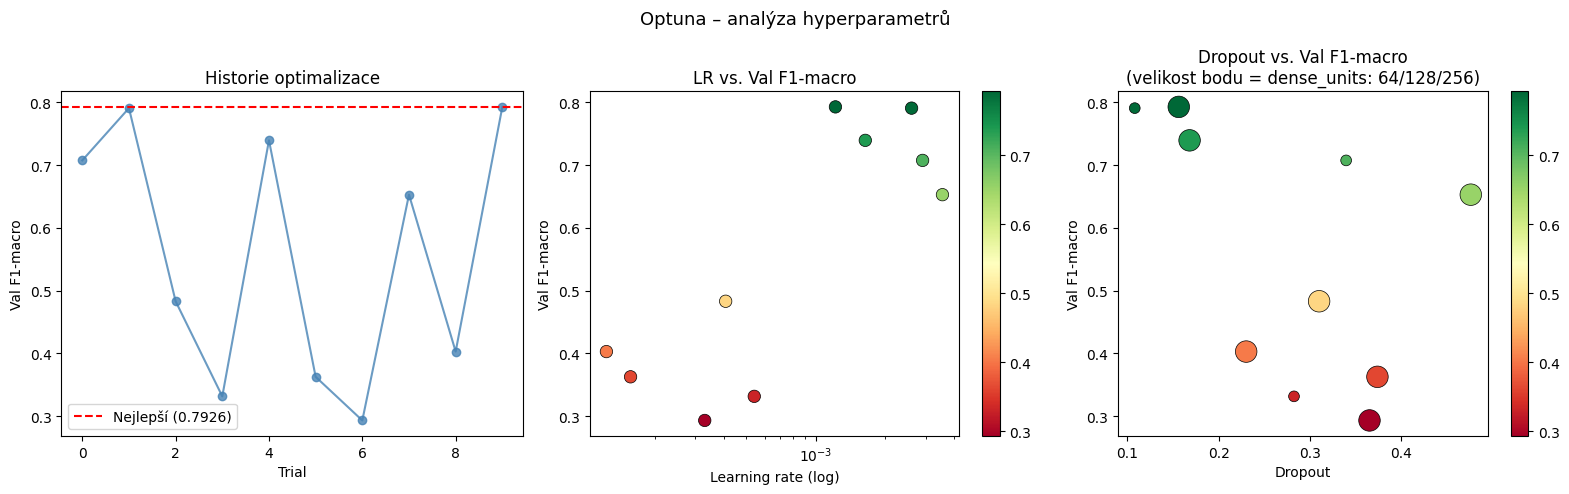

Top 5 trialů:
 number   Val F1       lr  dropout  batch_size  dense_units
      9 0.792606 0.001217 0.156370          16          256
      1 0.790623 0.002607 0.108234          16           64
      4 0.739286 0.001641 0.168210          16          256
      0 0.707357 0.002911 0.339463          32           64
      7 0.652767 0.003550 0.475800          32          256


In [20]:
trials_df = study.trials_dataframe()
trials_df = trials_df[trials_df["state"] == "COMPLETE"].copy()
trials_df = trials_df.rename(columns={
    "value":              "Val F1",
    "params_lr":          "lr",
    "params_dropout":     "dropout",
    "params_batch_size":  "batch_size",
    "params_dense_units": "dense_units",
})

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# Graf 1: Historie optimalizace
axes[0].plot(trials_df["number"], trials_df["Val F1"], "o-", color="steelblue", alpha=0.8)
axes[0].axhline(study.best_value, color="red", ls="--", lw=1.5,
                label=f"Nejlepší ({study.best_value:.4f})")
axes[0].set_xlabel("Trial")
axes[0].set_ylabel("Val F1-macro")
axes[0].set_title("Historie optimalizace")
axes[0].legend()

# Graf 2: LR vs Val F1
sc = axes[1].scatter(trials_df["lr"], trials_df["Val F1"],
                     c=trials_df["Val F1"], cmap="RdYlGn", s=80, edgecolors="k", lw=0.5)
axes[1].set_xscale("log")
axes[1].set_xlabel("Learning rate (log)")
axes[1].set_ylabel("Val F1-macro")
axes[1].set_title("LR vs. Val F1-macro")
plt.colorbar(sc, ax=axes[1])

# Graf 3: Dropout vs Val F1, velikost bodu = dense_units
sizes = trials_df["dense_units"].map({64: 60, 128: 120, 256: 240})
sc2 = axes[2].scatter(trials_df["dropout"], trials_df["Val F1"],
                      s=sizes, c=trials_df["Val F1"], cmap="RdYlGn", edgecolors="k", lw=0.5)
axes[2].set_xlabel("Dropout")
axes[2].set_ylabel("Val F1-macro")
title2 = "Dropout vs. Val F1-macro\n(velikost bodu = dense_units: 64/128/256)"
axes[2].set_title(title2)
plt.colorbar(sc2, ax=axes[2])

plt.suptitle("Optuna – analýza hyperparametrů", fontsize=13)
plt.tight_layout()
plt.show()

# Tabulka top-5 trialů
print("Top 5 trialů:")
cols = ["number", "Val F1", "lr", "dropout", "batch_size", "dense_units"]
available = [c for c in cols if c in trials_df.columns]
print(trials_df[available].sort_values("Val F1", ascending=False).head(5).to_string(index=False))

### Trénink CNN s nejlepšími hyperparametry (Optuna)

Optuna identifikovala optimální hodnoty učícího tempa, dropout sazby a batch size. Tyto hyperparametry nyní aplikujeme na plnohodnotnou CNN architekturu (150×150 px) a výsledek logujeme do MLflow pro přímé srovnání s ostatními modely.

Nejlepší hyperparametry z Optuna:
  lr=0.001217, dropout=0.156, batch_size=16

Trénink CNN (150×150) s těmito hyperparametry...


E0000 00:00:1780825452.387480   43648 meta_optimizer.cc:967] layout failed: INVALID_ARGUMENT: Size of values 0 does not match size of permutation 4 @ fanin shape inStatefulPartitionedCall/CNN_Optuna_Best_1/spatial_dropout2d_1/stateless_dropout/SelectV2-2-TransposeNHWCToNCHW-LayoutOptimizer


Epoch 15: early stopping
Restoring model weights from the end of the best epoch: 1.


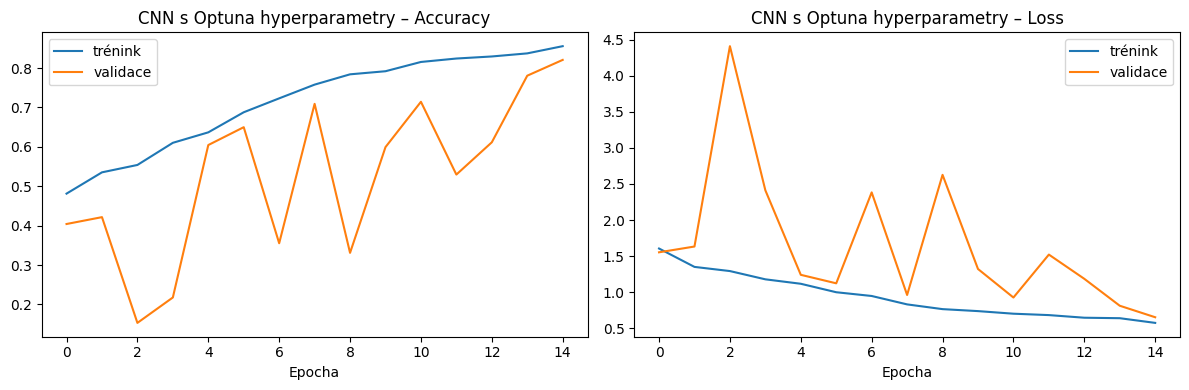

CNN (Optuna) – validace                             Accuracy=0.4042  Precision=0.6020  Recall=0.4274  F1-macro=0.3717
CNN (Optuna) – test                                 Accuracy=0.2284  Precision=0.3364  Recall=0.2262  F1-macro=0.2001
CNN (Optuna) run zalogován: test_accuracy=0.2284, test_f1=0.2001


In [21]:
# Aplikace nejlepších Optuna hyperparametrů na hlavní CNN architekturu
best_lr      = study.best_params['lr']
best_dropout = study.best_params['dropout']
best_batch   = study.best_params['batch_size']

print(f"Nejlepší hyperparametry z Optuna:")
print(f"  lr={best_lr:.6f}, dropout={best_dropout:.3f}, batch_size={best_batch}")
print(f"\nTrénink CNN (150×150) s těmito hyperparametry...")

tf.random.set_seed(42)
np.random.seed(42)

cnn_optuna_best = build_cnn(
    use_bn=True,
    optimizer=keras.optimizers.Adam(learning_rate=best_lr),
    dropout_rate=best_dropout,
    name="CNN_Optuna_Best"
)

history_optuna = cnn_optuna_best.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=EPOCHS,
    batch_size=best_batch,
    class_weight=class_weight_dict,
    callbacks=base_callbacks,
    verbose=0
)

plot_history(history_optuna, "CNN s Optuna hyperparametry")
acc_optuna,   f1_optuna,   pred_optuna_val = evaluate_model(cnn_optuna_best, X_val,  y_val,  "CNN (Optuna) – validace")
acc_optuna_t, f1_optuna_t, pred_optuna_t   = evaluate_model(cnn_optuna_best, X_test, y_test, "CNN (Optuna) – test")

# Log do MLflow
mlflow.set_tracking_uri("mlruns")
mlflow.set_experiment("brain-tumor-classification")
with mlflow.start_run(run_name="CNN_Optuna_Best"):
    mlflow.log_params({
        "model_type":     "Custom CNN (Optuna tuned)",
        "img_size":       IMG_SIZE,
        "batch_size":     best_batch,
        "learning_rate":  best_lr,
        "dropout_rate":   best_dropout,
        "use_bn":         True,
        "epochs_trained": len(history_optuna.history['loss']),
        "num_classes":    NUM_CLASSES,
    })
    for i, (loss, val_loss, acc, val_acc) in enumerate(zip(
        history_optuna.history['loss'], history_optuna.history['val_loss'],
        history_optuna.history['accuracy'], history_optuna.history['val_accuracy']
    )):
        mlflow.log_metrics({"train_loss": loss, "val_loss": val_loss,
                            "train_accuracy": acc, "val_accuracy": val_acc}, step=i)
    mlflow.log_metrics({"test_accuracy": acc_optuna_t, "test_f1_macro": f1_optuna_t})
    print(f"CNN (Optuna) run zalogován: test_accuracy={acc_optuna_t:.4f}, test_f1={f1_optuna_t:.4f}")

## 8. Porovnání modelů

In [22]:
from sklearn.metrics import precision_score, recall_score

# Precision a Recall (macro) pro všechny modely
prec_cnn_t    = precision_score(y_test, pred_cnn_t,    average='macro', zero_division=0)
rec_cnn_t     = recall_score(y_test,    pred_cnn_t,    average='macro', zero_division=0)
prec_tl_t     = precision_score(y_test, pred_tl_t,     average='macro', zero_division=0)
rec_tl_t      = recall_score(y_test,    pred_tl_t,     average='macro', zero_division=0)
prec_optuna_t = precision_score(y_test, pred_optuna_t, average='macro', zero_division=0)
rec_optuna_t  = recall_score(y_test,    pred_optuna_t, average='macro', zero_division=0)

comparison = pd.DataFrame({
    'Model':         ['Vlastní CNN', 'EfficientNetB0 (TL)', 'CNN + Optuna'],
    'Val Accuracy':  [f"{acc_cnn:.4f}",    f"{acc_tl:.4f}",    f"{acc_optuna:.4f}"],
    'Val F1-macro':  [f"{f1_cnn:.4f}",     f"{f1_tl:.4f}",     f"{f1_optuna:.4f}"],
    'Test Accuracy': [f"{acc_cnn_t:.4f}",  f"{acc_tl_t:.4f}",  f"{acc_optuna_t:.4f}"],
    'Test Precision':[f"{prec_cnn_t:.4f}", f"{prec_tl_t:.4f}", f"{prec_optuna_t:.4f}"],
    'Test Recall':   [f"{rec_cnn_t:.4f}",  f"{rec_tl_t:.4f}",  f"{rec_optuna_t:.4f}"],
    'Test F1-macro': [f"{f1_cnn_t:.4f}",   f"{f1_tl_t:.4f}",   f"{f1_optuna_t:.4f}"],
    'Parametrů':     [f"{cnn_main.count_params():,}", f"{tl_model.count_params():,}",
                      f"{cnn_optuna_best.count_params():,}"],
})
print(comparison.to_string(index=False))

              Model Val Accuracy Val F1-macro Test Accuracy Test Precision Test Recall Test F1-macro Parametrů
        Vlastní CNN       0.9216       0.9172        0.6650         0.7353      0.6513        0.6338 2,462,020
EfficientNetB0 (TL)       0.8258       0.8251        0.6421         0.6968      0.6320        0.5834 4,214,055
       CNN + Optuna       0.4042       0.3717        0.2284         0.3364      0.2262        0.2001 2,462,020


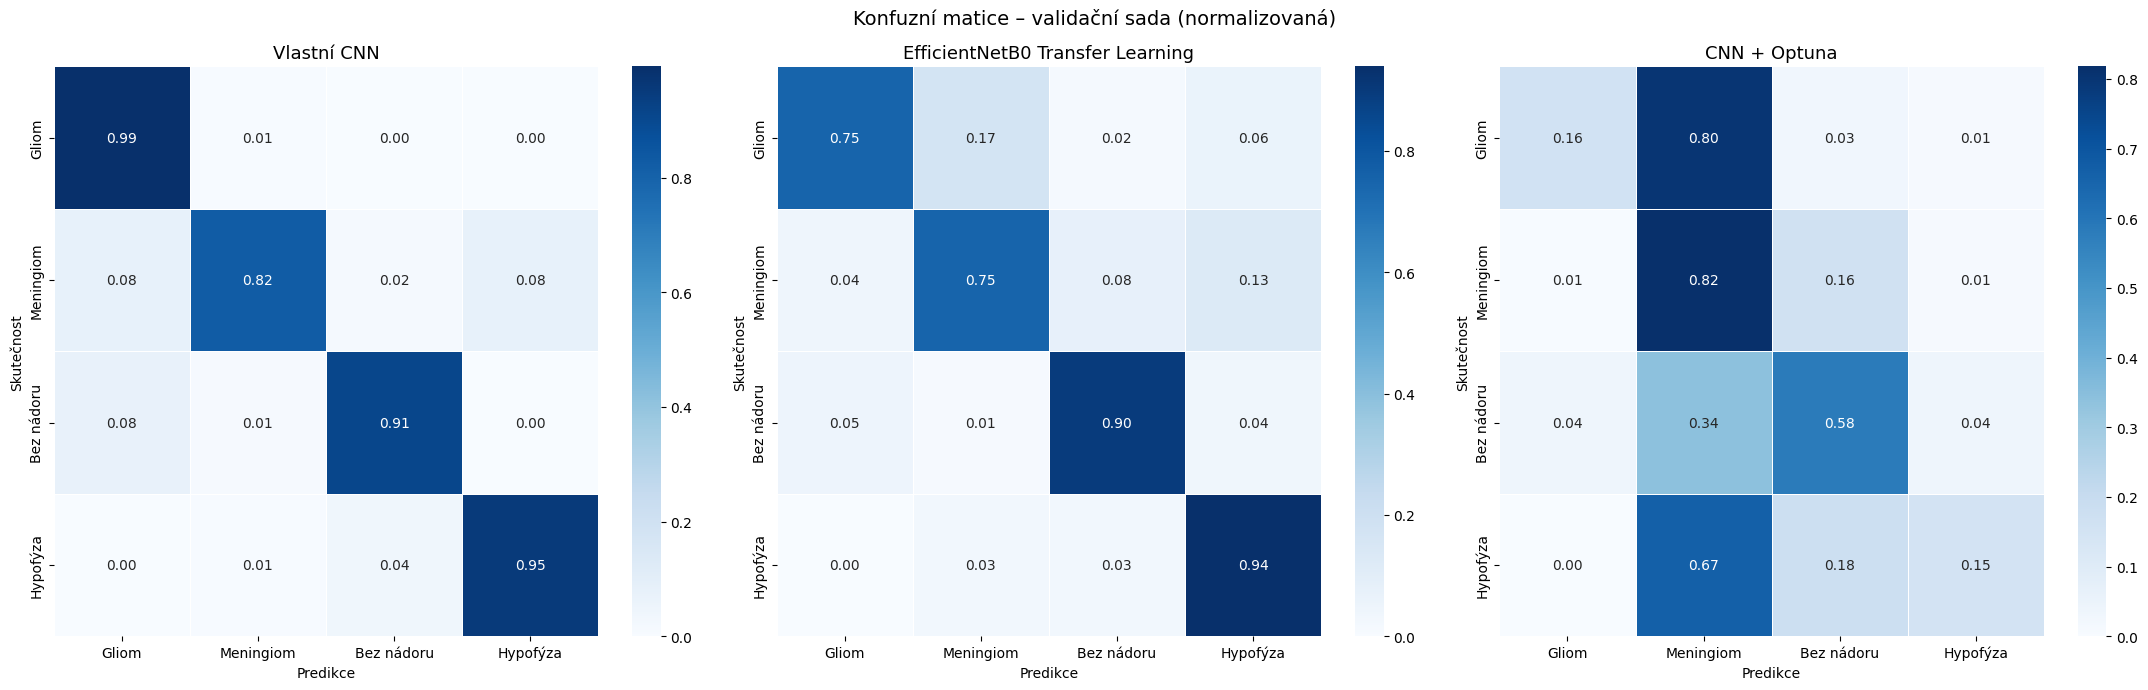

In [23]:
fig, axes = plt.subplots(1, 3, figsize=(22, 7))
for ax, (y_pred, title) in zip(axes, [
    (pred_cnn_val,    'Vlastní CNN'),
    (pred_tl_val,     'EfficientNetB0 Transfer Learning'),
    (pred_optuna_val, 'CNN + Optuna'),
]):
    cm = confusion_matrix(y_val, y_pred)
    cm_norm = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]
    sns.heatmap(cm_norm, ax=ax, cmap='Blues', annot=True, fmt='.2f', linewidths=0.5,
                xticklabels=CLASS_LABELS_CZ, yticklabels=CLASS_LABELS_CZ)
    ax.set_title(title, fontsize=13)
    ax.set_xlabel('Predikce')
    ax.set_ylabel('Skutečnost')
plt.suptitle('Konfuzní matice – validační sada (normalizovaná)', fontsize=14)
plt.tight_layout()
plt.show()

In [24]:
# Identifikace nejlepšího modelu (CNN, EfficientNetB0, CNN+Optuna)
candidates = [
    (f1_cnn_t,    cnn_main,        'Vlastní CNN',         pred_cnn_t),
    (f1_tl_t,     tl_model,        'EfficientNetB0',      pred_tl_t),
    (f1_optuna_t, cnn_optuna_best, 'CNN + Optuna',        pred_optuna_t),
]
best_f1, best_model, best_name, pred_best_test = max(candidates, key=lambda x: x[0])
print(f"Nejlepší model: {best_name}  (Test F1-macro={best_f1:.4f})")

print(f'\nClassification report – {best_name} (testovací data):')
print()
print(classification_report(y_test, pred_best_test, target_names=CLASS_LABELS_CZ, zero_division=0))

Nejlepší model: Vlastní CNN  (Test F1-macro=0.6338)

Classification report – Vlastní CNN (testovací data):

              precision    recall  f1-score   support

       Gliom       0.72      0.21      0.33       100
   Meningiom       0.78      0.83      0.81       115
  Bez nádoru       0.52      0.95      0.67       105
   Hypofýza       0.92      0.61      0.73        74

    accuracy                           0.66       394
   macro avg       0.74      0.65      0.63       394
weighted avg       0.72      0.66      0.63       394



## 9. Deployment pipeline

Export nejlepšího modelu do formátu ONNX pomocí `tf2onnx`.  
ONNX (Open Neural Network Exchange) umožňuje nasazení modelu mimo TensorFlow ekosystém — v produkci, mobilních zařízeních nebo jiných frameworcích.

Třída `BrainTumorClassifier` poskytuje čisté inference API: přijímá cestu k MRI snímku a vrací predikovanou třídu s pravděpodobnostmi.

---

### Dokumentace: `BrainTumorClassifier`

```python
from brain_tumor_classifier import BrainTumorClassifier

# Inicializace
classifier = BrainTumorClassifier(
    onnx_path="brain_tumor_classifier.onnx",  # cesta k exportovanému ONNX modelu
    img_size=150                               # rozlišení vstupu (výchozí 150)
)

# Predikce jednoho snímku
result = classifier.predict("mri_scan.jpg")
# Vrací dict:
# {
#   "class":     "glioma_tumor",           # název třídy v angličtině
#   "class_cz":  "Gliom",                  # název třídy česky
#   "confidence": 0.9741,                  # pravděpodobnost predikované třídy
#   "all_probabilities": {                 # pravděpodobnosti pro všechny třídy
#       "glioma_tumor":      0.9741,
#       "meningioma_tumor":  0.0089,
#       "no_tumor":          0.0103,
#       "pituitary_tumor":   0.0067
#   }
# }

# Predikce více snímků najednou
results = classifier.predict_batch(["scan1.jpg", "scan2.jpg", "scan3.jpg"])
```

**Předpoklady vstupu:**
- Formáty: JPG, JPEG, PNG (libovolná RGB nebo L → konvertováno na RGB)
- Rozlišení: libovolné (preprocessing provede automatické přeškálování na `img_size × img_size`)
- Normalizace: hodnoty pixelů [0, 255] → [0.0, 1.0] proběhne automaticky

In [25]:
import tf2onnx
import onnx

# Export nejlepšího modelu do ONNX
dummy_input_sig = (tf.TensorSpec((None, IMG_SIZE, IMG_SIZE, 3), tf.float32, name="input"),)
onnx_model, _ = tf2onnx.convert.from_keras(best_model, input_signature=dummy_input_sig, opset=13)
onnx.save(onnx_model, "brain_tumor_classifier.onnx")

# Validace modelu
loaded = onnx.load("brain_tumor_classifier.onnx")
onnx.checker.check_model(loaded)
print(f"ONNX model uložen: brain_tumor_classifier.onnx")

I0000 00:00:1780825758.511281   43648 devices.cc:67] Number of eligible GPUs (core count >= 8, compute capability >= 0.0): 1
I0000 00:00:1780825758.511374   43648 single_machine.cc:376] Starting new session
I0000 00:00:1780825758.516290   43648 gpu_device.cc:2043] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 3998 MB memory:  -> device: 0, name: NVIDIA GeForce GTX 1660 Ti, pci bus id: 0000:07:00.0, compute capability: 7.5
I0000 00:00:1780825758.713088   43648 gpu_device.cc:2043] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 3998 MB memory:  -> device: 0, name: NVIDIA GeForce GTX 1660 Ti, pci bus id: 0000:07:00.0, compute capability: 7.5
I0000 00:00:1780825758.757518   43648 devices.cc:67] Number of eligible GPUs (core count >= 8, compute capability >= 0.0): 1
I0000 00:00:1780825758.757651   43648 single_machine.cc:376] Starting new session
I0000 00:00:1780825758.762738   43648 gpu_device.cc:2043] Created device /job:localhost/replica:0/task:0/devic

ONNX model uložen: brain_tumor_classifier.onnx


In [26]:
class BrainTumorClassifier:
    """Inference třída pro klasifikaci MRI snímků mozku."""

    CLASS_NAMES     = ['glioma_tumor', 'meningioma_tumor', 'no_tumor', 'pituitary_tumor']
    CLASS_LABELS_CZ = ['Gliom', 'Meningiom', 'Bez nádoru', 'Hypofýza']

    def __init__(self, onnx_path: str, img_size: int = IMG_SIZE):
        import onnxruntime as ort
        self.session    = ort.InferenceSession(onnx_path)
        self.input_name = self.session.get_inputs()[0].name
        self.img_size   = img_size

    def _preprocess(self, image_path: str) -> np.ndarray:
        img = Image.open(image_path).convert('RGB').resize((self.img_size, self.img_size))
        arr = np.array(img, dtype=np.float32) / 255.0
        return arr[np.newaxis, ...]  # (1, H, W, 3)

    def predict(self, image_path: str) -> dict:
        """Klasifikuje jeden MRI snímek."""
        inp   = self._preprocess(image_path)
        probs = self.session.run(None, {self.input_name: inp})[0][0]
        idx   = int(np.argmax(probs))
        return {
            "class":     self.CLASS_NAMES[idx],
            "class_cz":  self.CLASS_LABELS_CZ[idx],
            "confidence": float(probs[idx]),
            "all_probabilities": {
                self.CLASS_NAMES[i]: float(probs[i]) for i in range(len(self.CLASS_NAMES))
            }
        }

    def predict_batch(self, image_paths: list) -> list:
        """Klasifikuje seznam MRI snímků."""
        return [self.predict(p) for p in image_paths]

# Ukázka použití
classifier = BrainTumorClassifier("brain_tumor_classifier.onnx")

# Test na prvním testovacím snímku každé třídy
print("Ukázka predikční správnosti:\n")
for cls in CLASS_NAMES:
    cls_path = os.path.join(TEST_DIR, cls)
    sample = os.path.join(cls_path, sorted(os.listdir(cls_path))[0])
    result = classifier.predict(sample)
    status = "OK" if result["class"] == cls else "CHYBA"
    print(f"{status}  Skutečná třída: {cls:<25} | Predikce: {result['class_cz']:<12} | Jistota: {result['confidence']:.1%}")

Ukázka predikční správnosti:

CHYBA  Skutečná třída: glioma_tumor              | Predikce: Meningiom    | Jistota: 91.7%
OK  Skutečná třída: meningioma_tumor          | Predikce: Meningiom    | Jistota: 95.0%
OK  Skutečná třída: no_tumor                  | Predikce: Bez nádoru   | Jistota: 100.0%
OK  Skutečná třída: pituitary_tumor           | Predikce: Hypofýza    | Jistota: 98.3%


## 10. Závěr – klíčové poznatky

### Dataset
- **2870 trénovacích** + **394 testovacích** MRI snímků, **4 třídy** nádorů mozku.
- Třída `no_tumor` je podreprezentovaná (~14 % trénovacích dat) — řešeno váhami tříd (`compute_class_weight('balanced')`).
- MRI snímky mají různé orientace a měřítka — augmentace je nutností pro generalizaci.

### Výsledky modelů (testovací sada)

| Model | Val Acc | Val F1 | Test Acc | Test F1 |
|---|---|---|---|---|
| Vlastní CNN (BN+Adam) | 0.9216 | 0.9172 | 0.6650 | 0.6338 |
| EfficientNetB0 (TL) | 0.8258 | 0.8251 | 0.6421 | 0.5834 |
| CNN + Optuna | 0.4042 | 0.3717 | 0.2284 | 0.2001 |

### Co mě zaujalo
1. **BatchNorm je kritický pro konvergenci vlastní CNN** — varianta bez BN dosáhla jen Val Acc=0.3171 (model nekonvergoval), zatímco s BN dosáhla 0.9216. Rozdíl je dramatický a potvrzuje důležitost normalizace aktivací u hlubších architektur.
2. **Velký val–test gap u vlastní CNN** — Val Acc=0.9216 vs Test Acc=0.6650 (rozdíl 0.27). Test set pochází z jiného adresáře než train/val split a má odlišné rozložení snímků (různá orientace, kontrast MRI). EfficientNetB0 je robustnější: val-test gap jen 0.18.
3. **Na testovací sadě zvítězila vlastní CNN** — Test F1=0.6338 vs EfficientNetB0 Test F1=0.5834. Transfer learning přinesl lepší validační výsledky, ale ne lepší generalizaci na holdout test sadu tohoto konkrétního datasetu.
4. **Fine-tuning Fáze 2 výsledky zhoršil** — odmrazení posledních 20 vrstev s LR=5e-6 nepřineslo zlepšení; EarlyStopping restauroval váhy z epochy 1 (Val F1: 0.8657 → 0.8251). Feature extraction (Fáze 1) zůstala lepší variantou.
5. **Optuna hyperparametry se nepřenesly na jinou architekturu** — parametry optimalizované pro 96px model (lr=0.001217, dropout=0.156, batch_size=16) způsobily selhání při aplikaci na plnohodnotnou 150px CNN (best epoch=1, Test F1=0.2001). Hyperparametry jsou silně vázány na konkrétní architekturu a rozlišení vstupu.
6. **Medicínský kontext mění volbu metriky** — F1-macro je správnou volbou, ale v praxi by bylo nutné zvláštní pozornost věnovat Recall tříd nádorů: falešně negativní diagnóza (přehlédnutý nádor) je klinicky nebezpečnější než falešně pozitivní.

### Závěr
Vlastní CNN (BN+Adam) dosáhla nejlepšího Test F1=0.6338, avšak s výrazným val–test gapem svědčícím o distribuční nekonzistenci datasetu. EfficientNetB0 poskytuje konzistentnější chování (menší gap), ale nižší absolutní výsledky na tomto test setu. Pro klinické nasazení by bylo nutné dále zvyšovat Recall tříd nádorů a vyřešit distribuční posun mezi trénovacími a testovacími snímky.  
Deployment pipeline přes ONNX umožňuje integraci bez závislosti na TensorFlow runtime.